# Análisis comparativo de correlaciones por modelo

Exploramos las correlaciones entre las métricas featurizadas y el resultado binario `WL_NUM` para comparar la señal que aporta cada versión del pipeline: **Baseline**, **Venue+** y **Enhanced**. Replicamos el análisis clásico de correlaciones, pero lo aplicamos de forma independiente a los tres conjuntos de features que se utilizan en `02_WL_estimator.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


import importlib.util, sys
spec = importlib.util.spec_from_file_location("feature_functions", "02_FeatureFunctions.py")
feature_functions = importlib.util.module_from_spec(spec)
sys.modules["feature_functions"] = feature_functions
spec.loader.exec_module(feature_functions)
from feature_functions import build_match_dataset_enhanced

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


In [2]:
# === Configuración ===
BASE_DIR = Path("/Users/pablo/Documents/BigData/BasketballAnalysis")
DATA_ROOT = BASE_DIR / "00_data/00d_featurized/2024-25"
FEATURIZED_PATH = DATA_ROOT / "teamgamelogs_featurized.parquet"

TARGET_COLUMN = "WL_NUM"
MAX_FEATURES_HEATMAP = 20
TOP_K_SCATTER = 5

if not FEATURIZED_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset featurizado en {FEATURIZED_PATH}.")
else:
    print(f"✅ Dataset encontrado en {FEATURIZED_PATH}")


✅ Dataset encontrado en /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/2024-25/teamgamelogs_featurized.parquet


In [3]:
# === Carga de datos ===
df = pd.read_parquet(FEATURIZED_PATH)
if TARGET_COLUMN not in df.columns:
    raise KeyError(f"La columna objetivo '{TARGET_COLUMN}' no está presente en el dataset featurizado.")

print(f"Shape del dataset: {df.shape}")


Shape del dataset: (2639, 103)


In [4]:
# === Dataset a nivel partido (diferenciales) ===
ADVANCED_FEATURES = [
    'WIN_STREAK', 'LAST_5_PCT', 'DAYS_REST', 'SEASON_W_PCT',
    'PACE', 'TURNOVER_RATIO'
]

X_all, y_all, meta_all = build_match_dataset_enhanced(
    df,
    numeric_feature_prefixes=("ROLL10_", "VENUE_"),
    advanced_features=ADVANCED_FEATURES,
)

if 'DIFF_B2B_FLAG' in X_all.columns:
    X_all = X_all.rename(columns={'DIFF_B2B_FLAG': 'B2B_ADVANTAGE'})

match_df = X_all.copy()
match_df[TARGET_COLUMN] = y_all

print(f"Shape dataset partido: {match_df.shape}")
match_df.head()


Shape dataset partido: (1311, 86)


,DIFF_ROLL10_AST,DIFF_ROLL10_AST_PCT,DIFF_ROLL10_AST_TOV,DIFF_ROLL10_BLK,DIFF_ROLL10_BLKA,DIFF_ROLL10_DEF_RATING,DIFF_ROLL10_DREB,DIFF_ROLL10_DREB_PCT,DIFF_ROLL10_EFG_PCT,DIFF_ROLL10_E_DEF_RATING,...,HOME_COURT,DIFF_VENUE_W_PCT,DIFF_WIN_STREAK,DIFF_LAST_5_PCT,DIFF_DAYS_REST,DIFF_SEASON_W_PCT,DIFF_PACE,DIFF_TURNOVER_RATIO,B2B_ADVANTAGE,WL_NUM
0,-0.500000,0.00000,0.00000,3.750000,2.000000,0.00000,5.000000,0.00000,0.00000,0.00000,...,1,0.124,-3,-0.5,1,-0.500000,0.00000,-0.020621,0,0
1,-2.800000,0.00000,0.00000,1.200000,-0.400000,0.00000,3.500000,0.00000,0.00000,0.00000,...,1,0.021,0,0.0,1,0.000000,0.00000,0.028870,0,0
2,-2.250000,0.00000,0.00000,3.250000,1.250000,0.00000,1.500000,0.00000,0.00000,0.00000,...,1,-0.103,-3,-0.5,0,-0.500000,0.00000,0.067020,0,0
3,-0.600000,0.00000,0.00000,1.000000,1.600000,0.00000,4.600000,0.00000,0.00000,0.00000,...,1,0.139,0,-0.6,0,-0.600000,0.00000,0.053616,0,1
4,0.111111,0.02026,0.10289,-0.166667,0.833333,5.61444,-1.666667,0.00354,0.00186,5.61444,...,1,0.227,-2,-0.6,0,-0.722222,8.10956,0.016435,0,1


## Conjuntos de features del pipeline

Tomamos exactamente las mismas listas de features que se utilizan en `02_WL_estimator.ipynb`. Cada conjunto representa una iteración del pipeline, añadiendo nuevas señales sobre la versión anterior.

In [5]:
# === Definición de features por modelo (copiado de 02_WL_estimator.ipynb) ===

def unique_preserve_order(seq):
    seen = set()
    ordered = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            ordered.append(item)
    return ordered

baseline_features = [c for c in match_df.columns if c.startswith('DIFF_ROLL10_') or c == 'HOME_COURT']
venue_features = baseline_features + [c for c in ['DIFF_VENUE_W_PCT'] if c in match_df.columns]
enhanced_candidates = [
    'DIFF_WIN_STREAK', 'DIFF_LAST_5_PCT', 'DIFF_DAYS_REST',
    'DIFF_SEASON_W_PCT', 'DIFF_PACE', 'DIFF_TURNOVER_RATIO', 'B2B_ADVANTAGE'
]
enhanced_features = venue_features + [c for c in enhanced_candidates if c in match_df.columns]

baseline_features = unique_preserve_order(baseline_features)
venue_features = unique_preserve_order(venue_features)
enhanced_features = unique_preserve_order(enhanced_features)

all_feature_columns = unique_preserve_order(baseline_features + venue_features + enhanced_features + [TARGET_COLUMN])
numeric_df = match_df[all_feature_columns].apply(pd.to_numeric, errors='coerce')
valid_numeric_columns = set(numeric_df.columns)
valid_numeric_columns.discard(TARGET_COLUMN)

feature_sets = {
    'Baseline': [f for f in baseline_features if f in valid_numeric_columns],
    'Venue+': [f for f in venue_features if f in valid_numeric_columns],
    'Enhanced': [f for f in enhanced_features if f in valid_numeric_columns],
}

MODEL_ORDER = list(feature_sets.keys())
incremental_feature_sets = {}
for idx, name in enumerate(MODEL_ORDER):
    if idx == 0:
        incremental_feature_sets[name] = feature_sets[name]
    else:
        prev = set(feature_sets[MODEL_ORDER[idx - 1]])
        incremental_feature_sets[name] = [f for f in feature_sets[name] if f not in prev]

features_overview = (
    pd.DataFrame(
        [(name, len(cols)) for name, cols in feature_sets.items()],
        columns=['Modelo', 'Nº de features']
    )
    .set_index('Modelo')
)

new_features_overview = (
    pd.DataFrame(
        [(name, len(cols)) for name, cols in incremental_feature_sets.items()],
        columns=['Modelo', 'Nº features nuevas vs anterior']
    )
    .set_index('Modelo')
)

display(features_overview.join(new_features_overview))
for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")
    print(', '.join(cols))
    if incremental_feature_sets[name] and name != MODEL_ORDER[0]:
        print(f"  Nuevas vs anterior ({len(incremental_feature_sets[name])}): {', '.join(incremental_feature_sets[name])}")
    elif name == MODEL_ORDER[0]:
        print("  Nuevas vs anterior: modelo inicial")
    else:
        print("  Nuevas vs anterior: --")
    print()


,Nº de features,Nº features nuevas vs anterior
Modelo,,
Baseline,76,76
Venue+,77,1
Enhanced,84,7


Baseline: 76 features
DIFF_ROLL10_AST, DIFF_ROLL10_AST_PCT, DIFF_ROLL10_AST_TOV, DIFF_ROLL10_BLK, DIFF_ROLL10_BLKA, DIFF_ROLL10_DEF_RATING, DIFF_ROLL10_DREB, DIFF_ROLL10_DREB_PCT, DIFF_ROLL10_EFG_PCT, DIFF_ROLL10_E_DEF_RATING, DIFF_ROLL10_E_NET_RATING, DIFF_ROLL10_E_OFF_RATING, DIFF_ROLL10_E_PACE, DIFF_ROLL10_FG3A, DIFF_ROLL10_FG3M, DIFF_ROLL10_FG3_PCT, DIFF_ROLL10_FGA, DIFF_ROLL10_FGM, DIFF_ROLL10_FG_PCT, DIFF_ROLL10_FTA, DIFF_ROLL10_FTM, DIFF_ROLL10_NET_RATING, DIFF_ROLL10_OFF_RATING, DIFF_ROLL10_OPP_PTS_2ND_CHANCE, DIFF_ROLL10_OPP_PTS_FB, DIFF_ROLL10_OPP_PTS_OFF_TOV, DIFF_ROLL10_OPP_PTS_PAINT, DIFF_ROLL10_OREB, DIFF_ROLL10_OREB_PCT, DIFF_ROLL10_PACE, DIFF_ROLL10_PACE_PER40, DIFF_ROLL10_PCT_AST_2PM, DIFF_ROLL10_PCT_AST_3PM, DIFF_ROLL10_PCT_AST_FGM, DIFF_ROLL10_PCT_DREB, DIFF_ROLL10_PCT_FGA, DIFF_ROLL10_PCT_FGA_2PT, DIFF_ROLL10_PCT_FGA_3PT, DIFF_ROLL10_PCT_FGM, DIFF_ROLL10_PCT_FTA, DIFF_ROLL10_PCT_FTM, DIFF_ROLL10_PCT_OREB, DIFF_ROLL10_PCT_PF, DIFF_ROLL10_PCT_PFD, DIFF_ROLL10_PCT_PTS,

### Qué aporta cada versión del modelo

- **Baseline**: incluye las diferencias en métricas `ROLL10` entre equipos y la bandera `HOME_COURT`, capturando la forma reciente y la ventaja de localía.
- **Venue+**: añade el rendimiento relativo por tipo de venue (`DIFF_VENUE_W_PCT`), lo que introduce información contextual sobre canchas neutrales o visitas prolongadas.
- **Enhanced**: suma rachas (`DIFF_WIN_STREAK`), estado reciente (`DIFF_LAST_5_PCT`, `DIFF_SEASON_W_PCT`), descanso (`DIFF_DAYS_REST`, `B2B_ADVANTAGE`) y ajustes de ritmo/seguridad del balón (`DIFF_PACE`, `DIFF_TURNOVER_RATIO`).

En los análisis siguientes distinguimos entre las señales heredadas y las nuevas de cada iteración para resaltar qué aporta cada bloque adicional.


## Funciones auxiliares para el análisis

Utilizamos utilidades comunes para replicar el análisis de correlaciones en cada conjunto de features.

In [6]:
def compute_correlations(frame, features, target):
    available = [f for f in features if f in frame.columns]
    if not available:
        return pd.Series(dtype=float)
    corr = frame[available + [target]].corr()[target].drop(target)
    return corr.dropna().sort_values(ascending=False)


def summarize_correlations(corr, top_n_pos=10, top_n_neg=10, weakest_n=5):
    if corr.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float)
    top_pos = corr.sort_values(ascending=False).head(min(top_n_pos, len(corr)))
    top_neg = corr.sort_values().head(min(top_n_neg, len(corr)))
    weakest = corr.abs().sort_values().head(min(weakest_n, len(corr)))
    return top_pos, top_neg, weakest


def plot_heatmap(frame, features, target, title, max_features=20):
    if not features:
        print(f"No hay features disponibles para {title}.")
        return
    ordered = frame[features + [target]].corr()[target].abs().sort_values(ascending=False).index.tolist()
    top_cols = [col for col in ordered if col != target][:max_features]
    corr_matrix = frame[top_cols + [target]].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title(title)
    plt.tight_layout()


def plot_scatter_grid(frame, features, target, title, top_k=5):
    if not features:
        print(f"No hay features disponibles para {title}.")
        return
    corr = frame[features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
    top_cols = corr.head(min(top_k, len(corr))).index.tolist()
    n_cols = len(top_cols)
    fig, axes = plt.subplots(nrows=1, ncols=n_cols, figsize=(4 * n_cols, 4), sharey=True)
    if n_cols == 1:
        axes = [axes]
    for ax, col in zip(axes, top_cols):
        sns.scatterplot(data=frame, x=col, y=target, alpha=0.3, ax=ax)
        ax.set_title(col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()


## Resumen de correlaciones por modelo

Calculamos las correlaciones con `WL_NUM` para cada conjunto y listamos las señales más fuertes, las más débiles y aquellas con correlación negativa más marcada.

In [7]:
analysis_state = {
    'model_correlations': {},
    'model_rankings': {},
    'incremental_correlations': {},
    'incremental_rankings': {},
}

for idx, model_name in enumerate(MODEL_ORDER):
    print(f"=== {model_name} ===")
    features = feature_sets[model_name]
    corr = compute_correlations(numeric_df, features, TARGET_COLUMN)
    analysis_state['model_correlations'][model_name] = corr

    top_pos, top_neg, weakest = summarize_correlations(corr)
    analysis_state['model_rankings'][model_name] = {
        'top_pos': top_pos,
        'top_neg': top_neg,
        'weakest': weakest,
    }

    print('Top 10 correlaciones positivas (todas las features disponibles)')
    display(top_pos.to_frame(name='Correlación'))

    print('Top 10 correlaciones negativas (todas las features disponibles)')
    display(top_neg.to_frame(name='Correlación'))

    print('5 correlaciones más débiles (en valor absoluto)')
    display(weakest.to_frame(name='|Correlación|'))

    new_features = incremental_feature_sets[model_name]
    available_new = [f for f in new_features if f in corr.index]
    new_corr = corr.loc[available_new] if available_new else pd.Series(dtype=float)
    analysis_state['incremental_correlations'][model_name] = new_corr

    if idx > 0:
        print('---')
        print(f"Señales nuevas introducidas en {model_name}")
        if new_corr.empty:
            print('No hay correlaciones disponibles para las nuevas features.')
            analysis_state['incremental_rankings'][model_name] = {
                'top_pos': pd.Series(dtype=float),
                'top_neg': pd.Series(dtype=float),
                'weakest': pd.Series(dtype=float),
            }
        else:
            new_top_pos, new_top_neg, new_weakest = summarize_correlations(new_corr)
            analysis_state['incremental_rankings'][model_name] = {
                'top_pos': new_top_pos,
                'top_neg': new_top_neg,
                'weakest': new_weakest,
            }
            print('Top correlaciones positivas (features nuevas)')
            display(new_top_pos.to_frame(name='Correlación'))
            print('Top correlaciones negativas (features nuevas)')
            display(new_top_neg.to_frame(name='Correlación'))
            print('5 correlaciones más débiles (features nuevas)')
            display(new_weakest.to_frame(name='|Correlación|'))
    else:
        analysis_state['incremental_rankings'][model_name] = {
            'top_pos': top_pos,
            'top_neg': top_neg,
            'weakest': weakest,
        }

    print()

model_correlations = analysis_state['model_correlations']
model_rankings = analysis_state['model_rankings']
incremental_correlations = analysis_state['incremental_correlations']
incremental_rankings = analysis_state['incremental_rankings']

globals().update({
    'model_correlations': model_correlations,
    'model_rankings': model_rankings,
    'incremental_correlations': incremental_correlations,
    'incremental_rankings': incremental_rankings,
})


=== Baseline ===
Top 10 correlaciones positivas (todas las features disponibles)


,Correlación
DIFF_ROLL10_PLUS_MINUS,0.332012
DIFF_ROLL10_NET_RATING,0.283023
DIFF_ROLL10_E_NET_RATING,0.283023
DIFF_ROLL10_PTS,0.220917
DIFF_ROLL10_FGM,0.216706
DIFF_ROLL10_FG_PCT,0.207282
DIFF_ROLL10_E_OFF_RATING,0.178596
DIFF_ROLL10_OFF_RATING,0.178596
DIFF_ROLL10_PTS_OFF_TOV,0.136660
DIFF_ROLL10_FG3_PCT,0.116291


Top 10 correlaciones negativas (todas las features disponibles)


,Correlación
DIFF_ROLL10_OPP_PTS_OFF_TOV,-0.235697
DIFF_ROLL10_DEF_RATING,-0.208317
DIFF_ROLL10_E_DEF_RATING,-0.208317
DIFF_ROLL10_TOV,-0.204748
DIFF_ROLL10_USG_PCT,-0.199133
DIFF_ROLL10_OPP_PTS_FB,-0.184330
DIFF_ROLL10_PCT_FTM,-0.182180
DIFF_ROLL10_PCT_FTA,-0.178116
DIFF_ROLL10_PCT_FGA,-0.163600
DIFF_ROLL10_TM_TOV_PCT,-0.161579


5 correlaciones más débiles (en valor absoluto)


...

,Correlación
DIFF_SEASON_W_PCT,0.283000
DIFF_LAST_5_PCT,0.264877
DIFF_WIN_STREAK,0.192037
DIFF_DAYS_REST,0.053645
DIFF_PACE,-0.001876
DIFF_TURNOVER_RATIO,-0.151800


Top correlaciones negativas (features nuevas)


,Correlación
DIFF_TURNOVER_RATIO,-0.151800
DIFF_PACE,-0.001876
DIFF_DAYS_REST,0.053645
DIFF_WIN_STREAK,0.192037
DIFF_LAST_5_PCT,0.264877
DIFF_SEASON_W_PCT,0.283000


5 correlaciones más débiles (features nuevas)


,|Correlación|
DIFF_PACE,0.001876
DIFF_DAYS_REST,0.053645
DIFF_TURNOVER_RATIO,0.151800
DIFF_WIN_STREAK,0.192037
DIFF_LAST_5_PCT,0.264877


## Heatmaps de las features más correlacionadas

Visualizamos la matriz de correlaciones entre las features más influyentes de cada modelo y el objetivo, replicando el análisis original para cada conjunto.

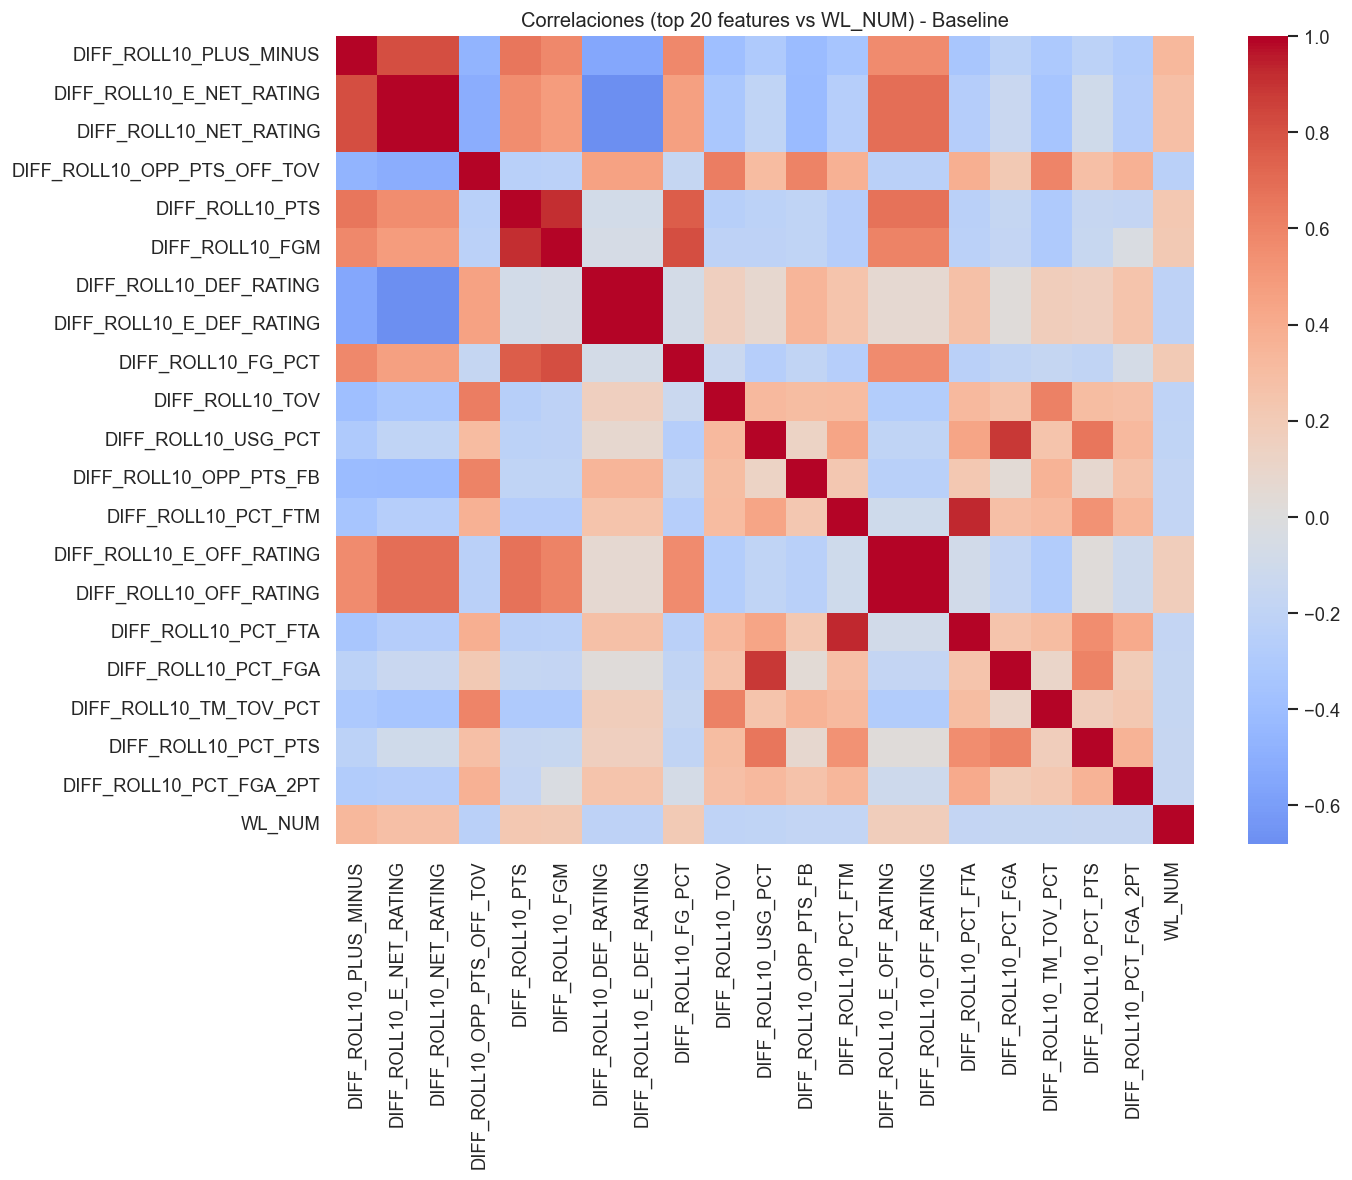

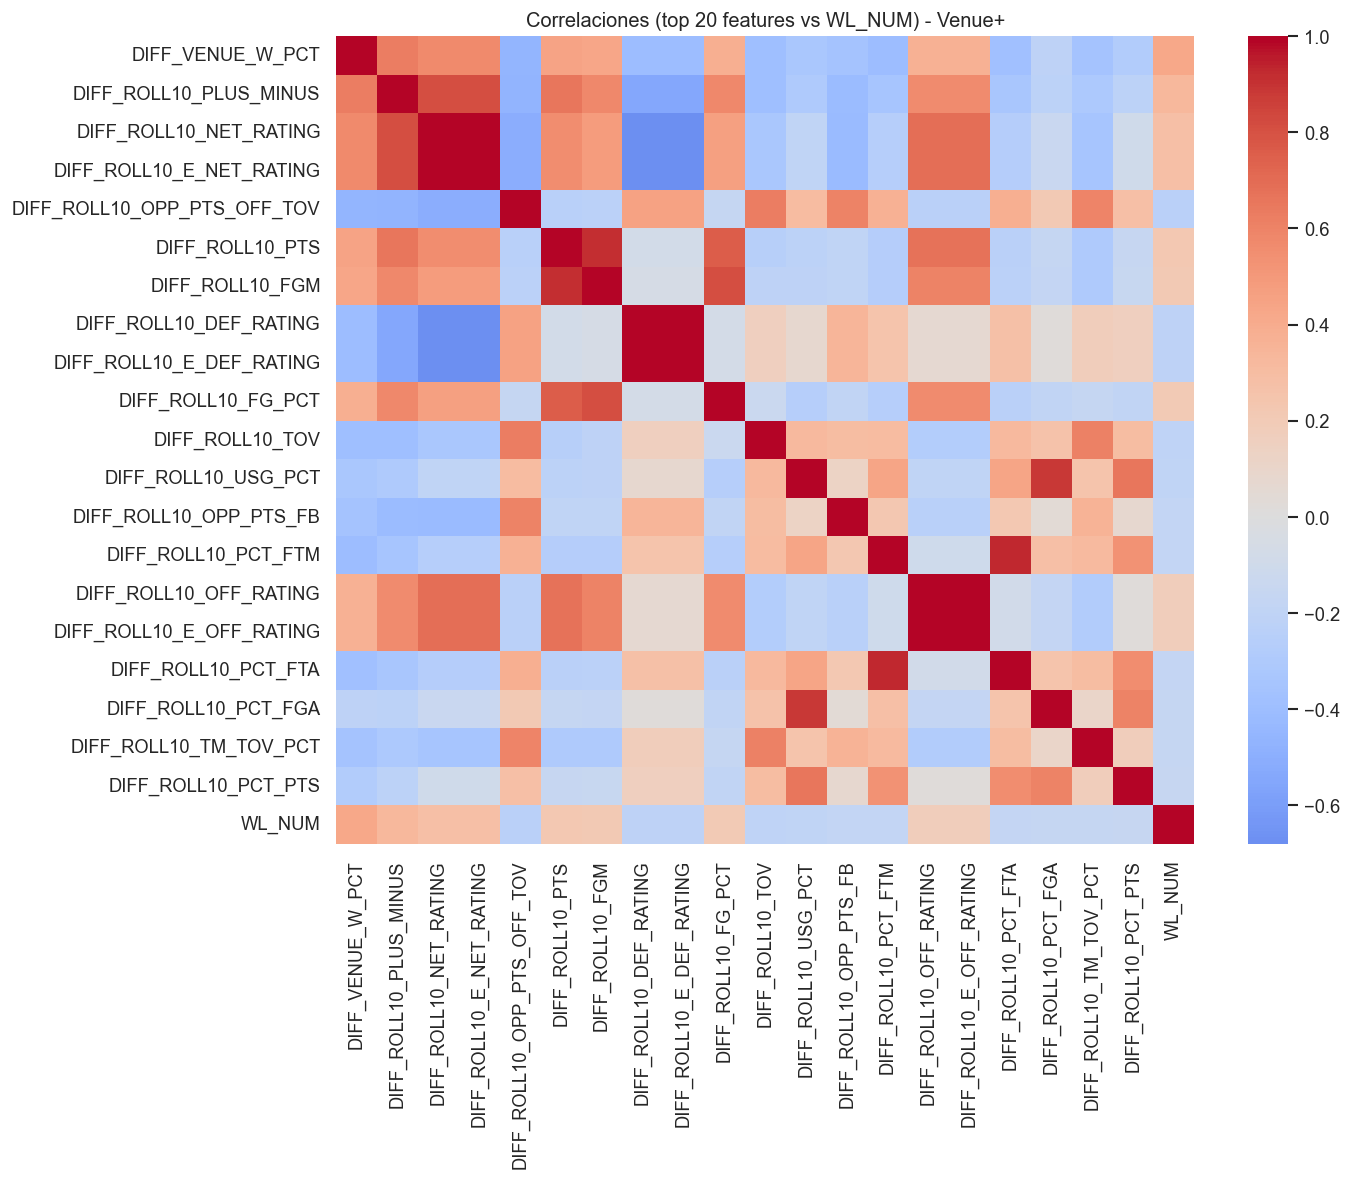

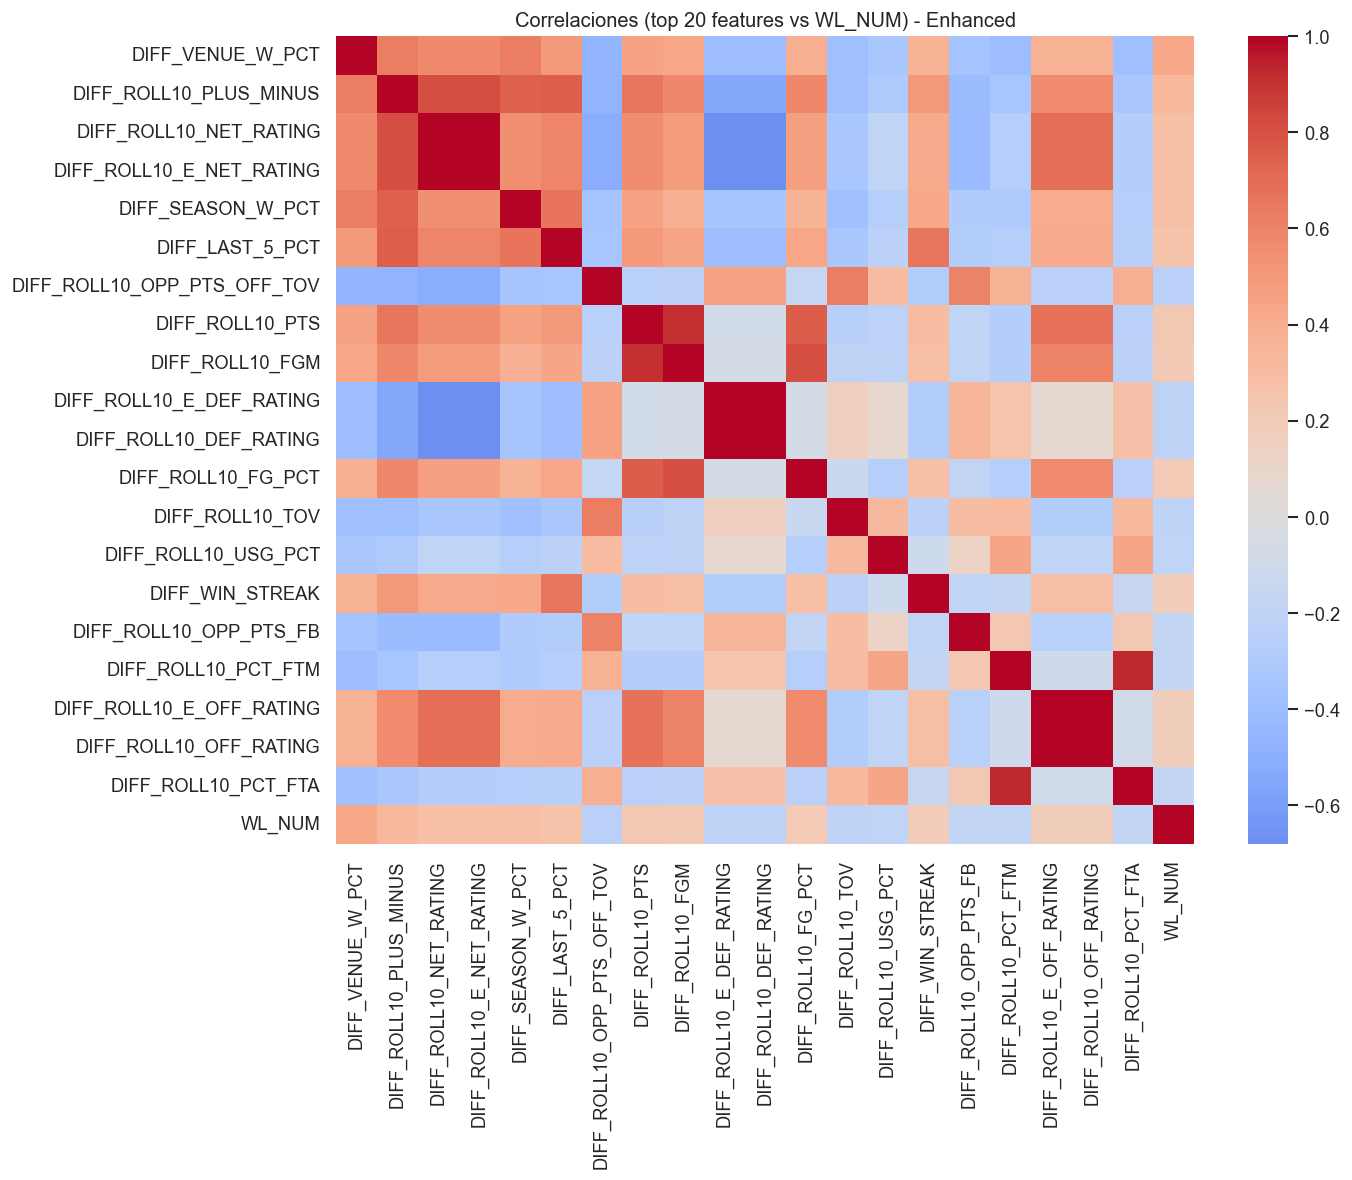

In [8]:
for model_name, corr in model_correlations.items():
    title = f"Correlaciones (top {MAX_FEATURES_HEATMAP} features vs WL_NUM) - {model_name}"
    plot_heatmap(numeric_df, feature_sets[model_name], TARGET_COLUMN, title, max_features=MAX_FEATURES_HEATMAP)


## Dispersión de las correlaciones más fuertes

Mostramos la relación entre `WL_NUM` y las cinco features con mayor correlación absoluta dentro de cada modelo.

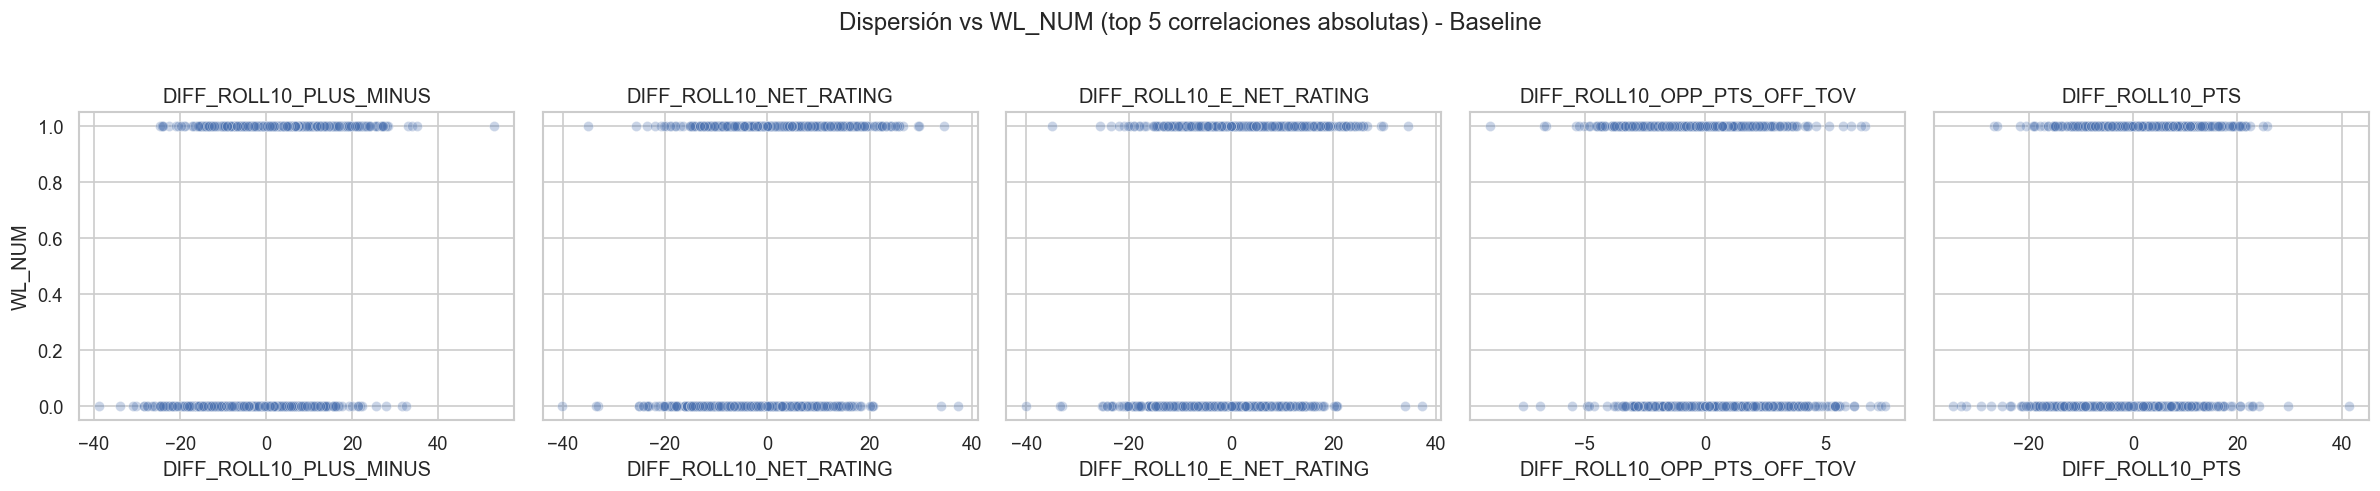

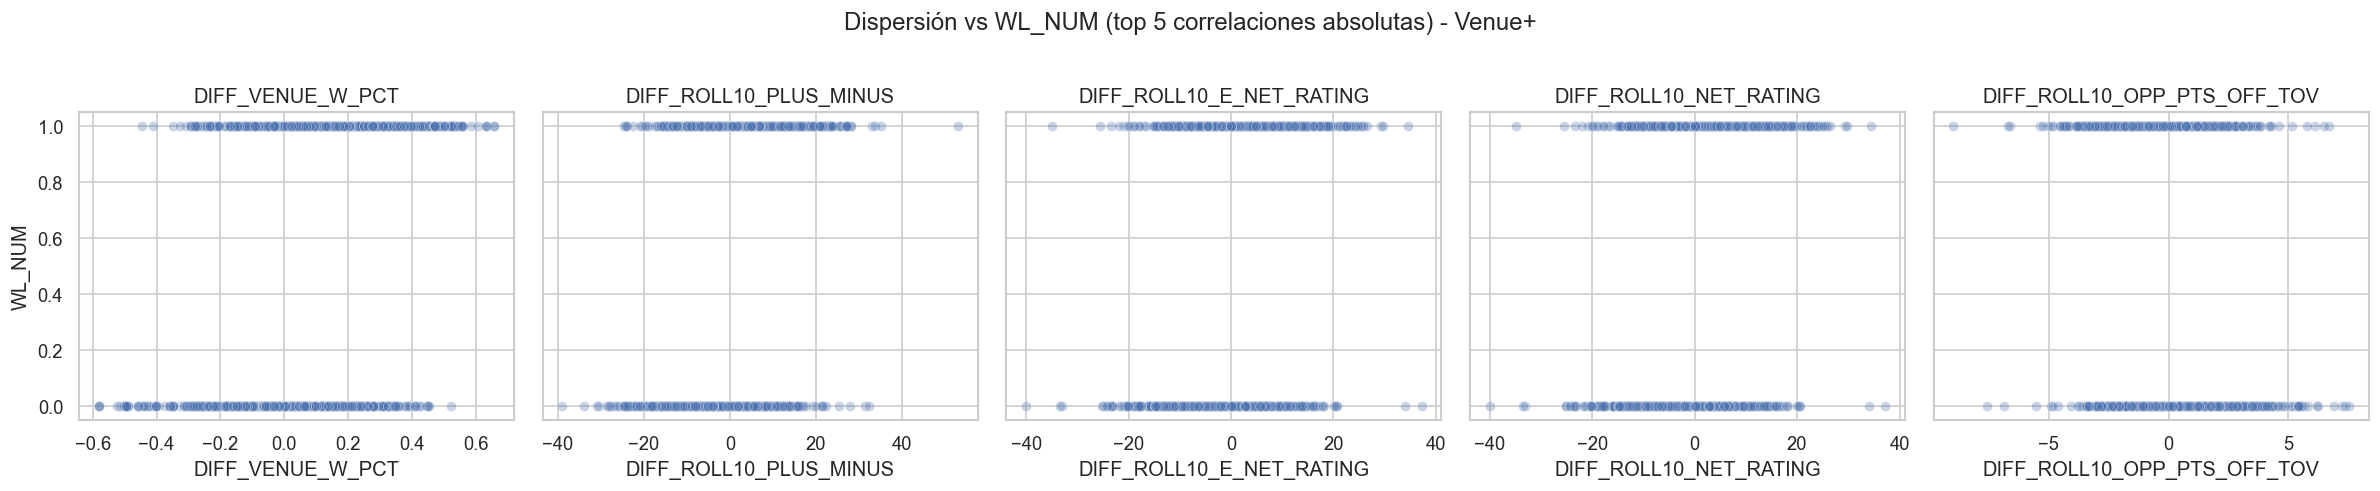

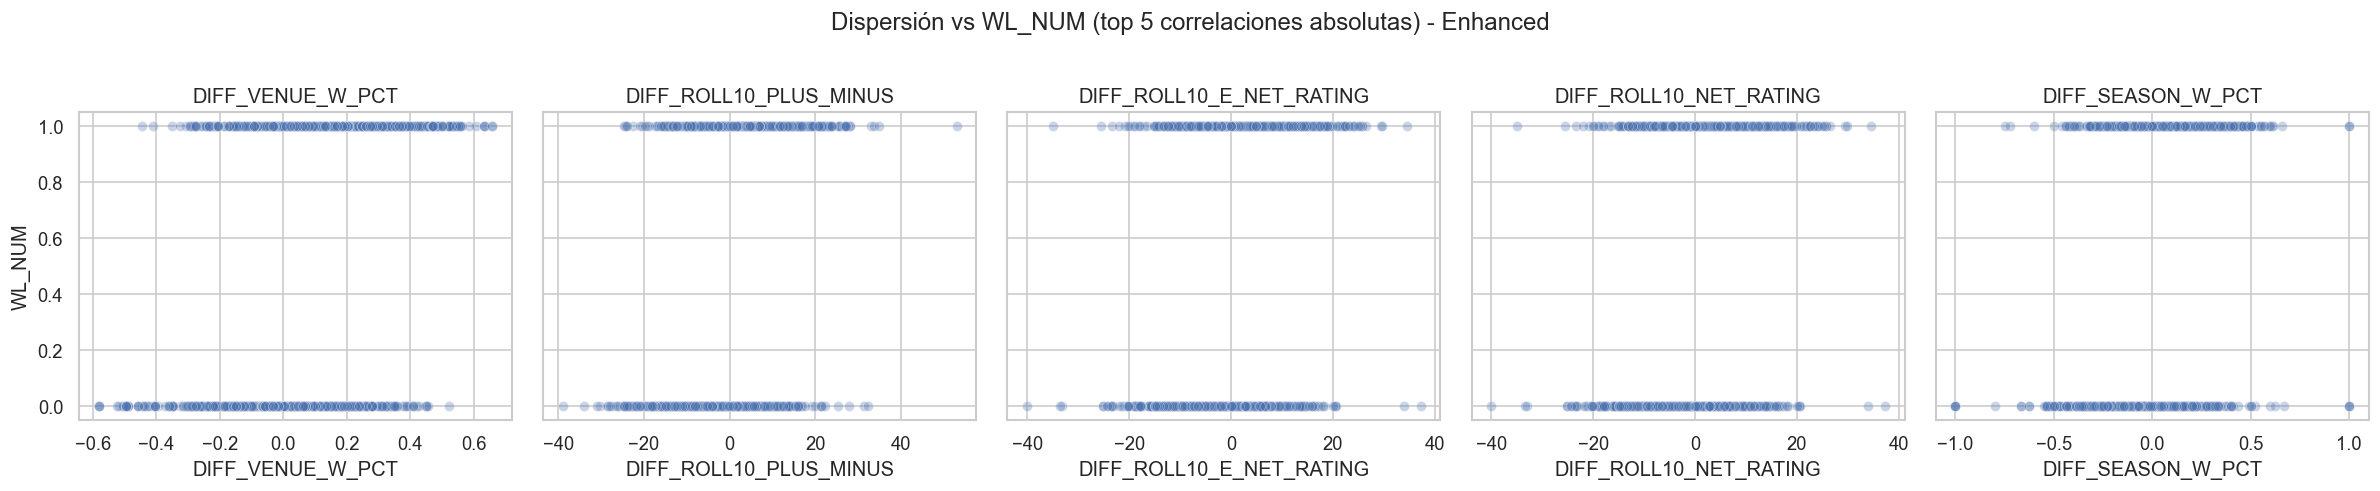

In [9]:
for model_name in feature_sets:
    title = f"Dispersión vs WL_NUM (top {TOP_K_SCATTER} correlaciones absolutas) - {model_name}"
    plot_scatter_grid(numeric_df, feature_sets[model_name], TARGET_COLUMN, title, top_k=TOP_K_SCATTER)


## Comparativa entre modelos

Evaluamos cómo evoluciona la fuerza de las correlaciones al pasar del modelo Baseline al Venue+ y al Enhanced.

,Feature correlación positiva máxima,Correlación positiva máxima,Feature correlación absoluta máxima,Correlación absoluta máxima,Feature nueva más correlacionada,Correlación feature nueva
Modelo,,,,,,
Baseline,DIFF_ROLL10_PLUS_MINUS,0.332012,DIFF_ROLL10_PLUS_MINUS,0.332012,DIFF_ROLL10_PLUS_MINUS,0.332012
Venue+,DIFF_VENUE_W_PCT,0.428888,DIFF_VENUE_W_PCT,0.428888,DIFF_VENUE_W_PCT,0.428888
Enhanced,DIFF_VENUE_W_PCT,0.428888,DIFF_VENUE_W_PCT,0.428888,DIFF_SEASON_W_PCT,0.283000


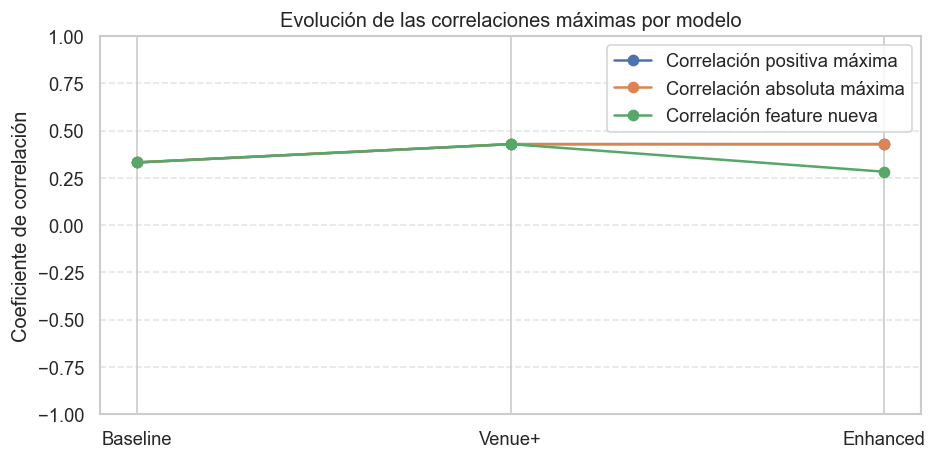

In [10]:
# Evolución de la correlación máxima (positiva, absoluta y nuevas features)
summary_rows = []
for model_name in MODEL_ORDER:
    corr = model_correlations.get(model_name, pd.Series(dtype=float))
    if corr.empty:
        continue
    max_pos_feature = corr.idxmax()
    max_pos_value = corr.loc[max_pos_feature]
    max_abs_feature = corr.abs().idxmax()
    max_abs_value = corr.abs().loc[max_abs_feature]

    new_corr = incremental_correlations.get(model_name, pd.Series(dtype=float))
    if not new_corr.empty:
        new_abs = new_corr.abs()
        top_new_feature = new_abs.idxmax()
        top_new_value = new_corr.loc[top_new_feature]
    else:
        top_new_feature = '—'
        top_new_value = np.nan

    summary_rows.append({
        'Modelo': model_name,
        'Feature correlación positiva máxima': max_pos_feature,
        'Correlación positiva máxima': max_pos_value,
        'Feature correlación absoluta máxima': max_abs_feature,
        'Correlación absoluta máxima': max_abs_value,
        'Feature nueva más correlacionada': top_new_feature,
        'Correlación feature nueva': top_new_value,
    })

max_corr_df = pd.DataFrame(summary_rows).set_index('Modelo')
display(max_corr_df)

plt.figure(figsize=(8, 4))
plt.plot(max_corr_df.index, max_corr_df['Correlación positiva máxima'], marker='o', label='Correlación positiva máxima')
plt.plot(max_corr_df.index, max_corr_df['Correlación absoluta máxima'], marker='o', label='Correlación absoluta máxima')
if not max_corr_df['Correlación feature nueva'].isna().all():
    plt.plot(max_corr_df.index, max_corr_df['Correlación feature nueva'], marker='o', label='Correlación feature nueva')
plt.title('Evolución de las correlaciones máximas por modelo')
plt.ylabel('Coeficiente de correlación')
plt.ylim(-1, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


In [11]:
# Tabla comparativa de poder predictivo (medimos estadísticos sobre las correlaciones absolutas)
power_rows = []
for model_name in MODEL_ORDER:
    corr = model_correlations.get(model_name, pd.Series(dtype=float))
    if corr.empty:
        continue
    abs_corr = corr.abs().sort_values(ascending=False)
    row = {
        'Modelo': model_name,
        'Media |corr| top 5': abs_corr.head(5).mean(),
        'Media |corr| top 10': abs_corr.head(10).mean(),
        'Mediana |corr| top 10': abs_corr.head(10).median(),
        'Máx |corr|': abs_corr.iloc[0],
        'Mín |corr| top 10': abs_corr.head(10).iloc[-1] if len(abs_corr) >= 10 else abs_corr.iloc[-1],
    }

    new_corr = incremental_correlations.get(model_name, pd.Series(dtype=float))
    if not new_corr.empty:
        abs_new_corr = new_corr.abs().sort_values(ascending=False)
        row.update({
            'Media |corr| (features nuevas)': abs_new_corr.mean(),
            'Máx |corr| (features nuevas)': abs_new_corr.iloc[0],
        })
    else:
        row.update({
            'Media |corr| (features nuevas)': np.nan,
            'Máx |corr| (features nuevas)': np.nan,
        })

    power_rows.append(row)

power_df = pd.DataFrame(power_rows).set_index('Modelo')
display(power_df)


,Media |corr| top 5,Media |corr| top 10,Mediana |corr| top 10,Máx |corr|,Mín |corr| top 10,Media |corr| (features nuevas),Máx |corr| (features nuevas)
Modelo,,,,,,,
Baseline,0.270934,0.240004,0.218812,0.332012,0.204748,0.106346,0.332012
Venue+,0.312529,0.262418,0.228307,0.428888,0.207282,0.428888,0.428888
Enhanced,0.321989,0.275646,0.273938,0.428888,0.208317,0.157872,0.283000


### Heatmaps comparativos

Colocamos los heatmaps de los tres modelos en paralelo para visualizar rápidamente las diferencias en bloques de correlación y, posteriormente, nos enfocamos solo en las señales nuevas de Venue+ y Enhanced.


Text(0.5, 1.03, 'Heatmaps comparativos (top features por modelo)')

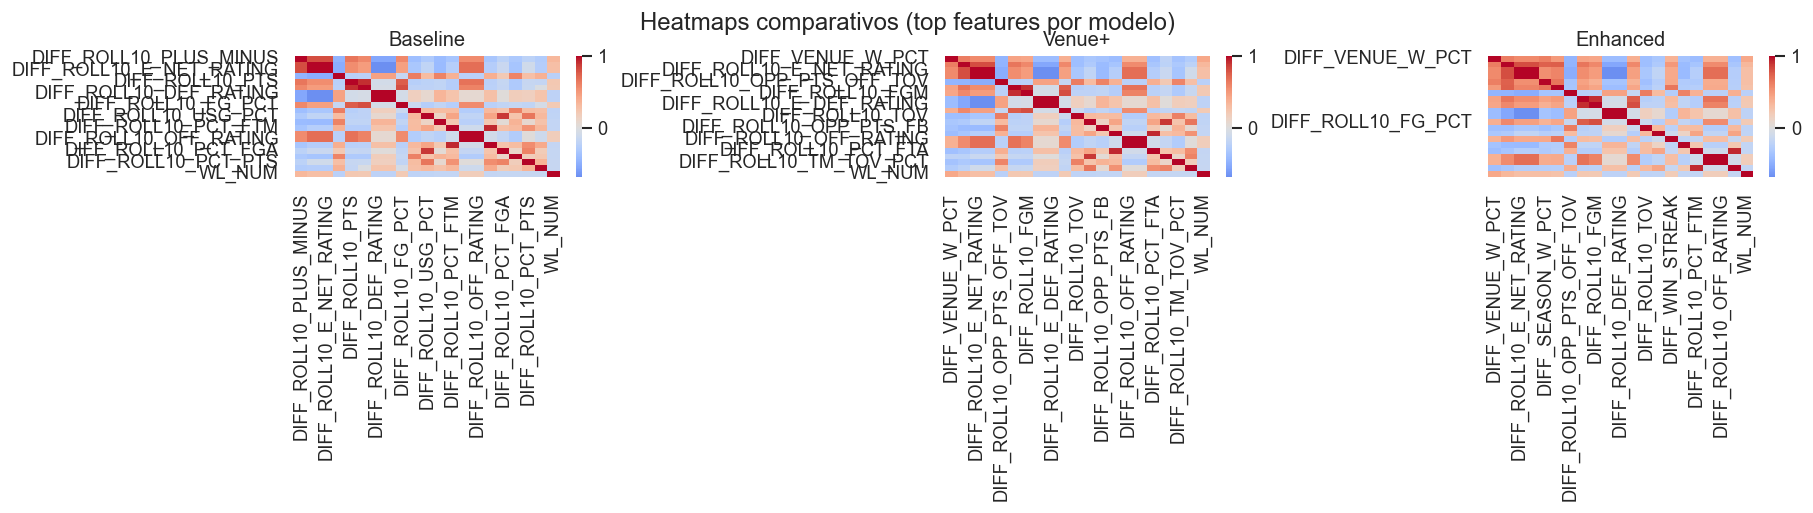

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=len(MODEL_ORDER), figsize=(5 * len(MODEL_ORDER), 4), constrained_layout=True)
if len(MODEL_ORDER) == 1:
    axes = [axes]
for ax, model_name in zip(axes, MODEL_ORDER):
    features = feature_sets[model_name]
    corr = model_correlations.get(model_name, pd.Series(dtype=float))
    if corr.empty:
        ax.set_visible(False)
        continue
    ordered = corr.abs().sort_values(ascending=False).index.tolist()
    top_cols = ordered[:MAX_FEATURES_HEATMAP]
    corr_matrix = numeric_df[top_cols + [TARGET_COLUMN]].corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(model_name)
plt.suptitle('Heatmaps comparativos (top features por modelo)', y=1.03)


### Heatmaps de las nuevas features

Resaltamos únicamente las columnas añadidas en cada salto del pipeline para aislar su contribución específica.


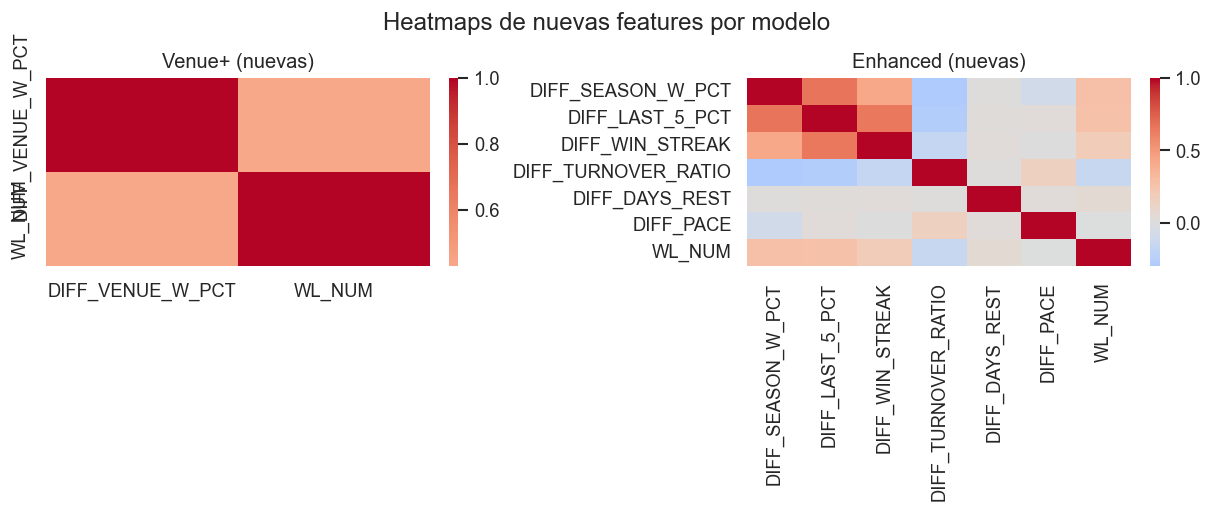

In [13]:
models_with_new = [name for idx, name in enumerate(MODEL_ORDER) if idx > 0 and incremental_feature_sets[name]]
if not models_with_new:
    print('No hay nuevas features que visualizar en heatmaps separados.')
else:
    fig, axes = plt.subplots(nrows=1, ncols=len(models_with_new), figsize=(5 * len(models_with_new), 4), constrained_layout=True)
    if len(models_with_new) == 1:
        axes = [axes]
    for ax, model_name in zip(axes, models_with_new):
        new_features = incremental_feature_sets[model_name]
        corr = incremental_correlations.get(model_name, pd.Series(dtype=float))
        if corr.empty:
            ax.set_visible(False)
            continue
        ordered = corr.abs().sort_values(ascending=False).index.tolist()
        top_cols = ordered[:MAX_FEATURES_HEATMAP]
        subset = numeric_df[top_cols + [TARGET_COLUMN]]
        corr_matrix = subset.corr()
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
        ax.set_title(f'{model_name} (nuevas)')
    plt.suptitle('Heatmaps de nuevas features por modelo', y=1.03)


## Qué nuevas features aportan más valor

Identificamos qué columnas incorporadas en cada versión posterior ofrecen las correlaciones absolutas más altas con respecto a `WL_NUM`.

In [14]:
def display_new_feature_summary(model_name, previous_model=None):
    new_cols = incremental_feature_sets[model_name]
    if previous_model is None:
        header = f"Impacto de las features del modelo {model_name} (modelo inicial)"
    else:
        header = f"Impacto de las nuevas features del modelo {model_name} (vs {previous_model})"
    print(header)
    if not new_cols:
        print('No se añadieron nuevas features en esta versión.')
        print()
        return

    corr = model_correlations.get(model_name, pd.Series(dtype=float))
    available = [c for c in new_cols if c in corr.index]
    if not available:
        print('No hay correlaciones disponibles para estas columnas.')
        print()
        return

    series = corr.loc[available]
    ordered = series.abs().sort_values(ascending=False)
    table = pd.DataFrame({
        'Correlación': series.loc[ordered.index],
        '|Correlación|': ordered,
    })
    max_rows = min(20, len(table))
    display(table.head(max_rows))
    if len(table) > max_rows:
        print(f'Se muestran los {max_rows} valores más altos de {len(table)} columnas disponibles.')

    top_pos, top_neg, weakest = summarize_correlations(series, top_n_pos=5, top_n_neg=5, weakest_n=min(5, len(series)))
    if not top_pos.empty:
        print('Top correlaciones positivas (features nuevas)')
        display(top_pos.to_frame(name='Correlación'))
    if not top_neg.empty:
        print('Top correlaciones negativas (features nuevas)')
        display(top_neg.to_frame(name='Correlación'))
    if not weakest.empty:
        print('Correlaciones más débiles (features nuevas)')
        display(weakest.to_frame(name='|Correlación|'))
    print()

for idx, model_name in enumerate(MODEL_ORDER):
    previous = MODEL_ORDER[idx - 1] if idx > 0 else None
    display_new_feature_summary(model_name, previous_model=previous)


Impacto de las features del modelo Baseline (modelo inicial)


,Correlación,|Correlación|
DIFF_ROLL10_PLUS_MINUS,0.332012,0.332012
DIFF_ROLL10_NET_RATING,0.283023,0.283023
DIFF_ROLL10_E_NET_RATING,0.283023,0.283023
DIFF_ROLL10_OPP_PTS_OFF_TOV,-0.235697,0.235697
DIFF_ROLL10_PTS,0.220917,0.220917
DIFF_ROLL10_FGM,0.216706,0.216706
DIFF_ROLL10_DEF_RATING,-0.208317,0.208317
DIFF_ROLL10_E_DEF_RATING,-0.208317,0.208317
DIFF_ROLL10_FG_PCT,0.207282,0.207282
DIFF_ROLL10_TOV,-0.204748,0.204748


Se muestran los 20 valores más altos de 75 columnas disponibles.
Top correlaciones positivas (features nuevas)


,Correlación
DIFF_ROLL10_PLUS_MINUS,0.332012
DIFF_ROLL10_NET_RATING,0.283023
DIFF_ROLL10_E_NET_RATING,0.283023
DIFF_ROLL10_PTS,0.220917
DIFF_ROLL10_FGM,0.216706


Top correlaciones negativas (features nuevas)


...

,Correlación
DIFF_SEASON_W_PCT,0.283000
DIFF_LAST_5_PCT,0.264877
DIFF_WIN_STREAK,0.192037
DIFF_DAYS_REST,0.053645
DIFF_PACE,-0.001876


Top correlaciones negativas (features nuevas)


,Correlación
DIFF_TURNOVER_RATIO,-0.151800
DIFF_PACE,-0.001876
DIFF_DAYS_REST,0.053645
DIFF_WIN_STREAK,0.192037
DIFF_LAST_5_PCT,0.264877


Correlaciones más débiles (features nuevas)


,|Correlación|
DIFF_PACE,0.001876
DIFF_DAYS_REST,0.053645
DIFF_TURNOVER_RATIO,0.151800
DIFF_WIN_STREAK,0.192037
DIFF_LAST_5_PCT,0.264877


### Interpretación de las mejoras

- **Del Baseline al Venue+**: el rendimiento relativo por tipo de venue permite capturar diferencias que las medias móviles no recogen, destacando qué equipos mejoran o empeoran fuera de casa y mostrando su correlación específica sin quedar eclipsada por las señales heredadas.
- **Del Venue+ al Enhanced**: las señales de rachas, descanso y estado reciente refuerzan la capacidad predictiva al reflejar la forma actual del equipo y su desgaste, aportando correlaciones absolutas más altas dentro del bloque de nuevas features.
- **Features más valiosas**: observamos qué variables nuevas (por ejemplo, `DIFF_WIN_STREAK` o `DIFF_DAYS_REST`) aparecen entre las correlaciones más fuertes de sus respectivos incrementos, guiando prioridades de ingeniería de features.


## Elo Dinámico (sin fuga) — Integración y análisis en 02_FeaturesCorrelation

Incorporamos un rating Elo que cuantifica la fuerza relativa de cada equipo, calculado en orden cronológico sin fuga de información.
Integramos estas señales en el análisis de correlaciones siguiendo exactamente el mismo flujo aplicado al resto de bloques de features.


### Calendario retrospectivo mínimo sin fuga

Preparamos señales básicas de calendario para cada equipo asegurando que solo utilicen partidos previos al actual.


In [16]:
# === Calendario retrospectivo mínimo (en df) ===
if 'GAME_DATE' not in df.columns:
    raise KeyError("La columna 'GAME_DATE' no está disponible en el dataset featurizado.")

# Aseguramos un datetime naïve en GAME_DATE
game_dates = pd.to_datetime(df['GAME_DATE'], errors='coerce', utc=True)
df['GAME_DATE'] = game_dates.dt.tz_convert(None)

sort_columns = [col for col in ['TEAM_ID', 'GAME_DATE', 'GAME_ID'] if col in df.columns]
if len(sort_columns) < 3:
    raise KeyError('No se encontraron todas las columnas necesarias para ordenar cronológicamente por equipo.')

# Crear un índice único temporal
sorted_df = df.sort_values(sort_columns).reset_index(drop=True)
sorted_df['temp_index'] = range(len(sorted_df))

sorted_df['PREV_GAME_DATE'] = sorted_df.groupby('TEAM_ID')['GAME_DATE'].shift(1)
sorted_df['DAYS_REST_CALC'] = (sorted_df['GAME_DATE'] - sorted_df['PREV_GAME_DATE']).dt.days
sorted_df['DAYS_REST_CALC'] = sorted_df['DAYS_REST_CALC'].fillna(0).clip(lower=0)
sorted_df['IS_B2B_CALC'] = (sorted_df['DAYS_REST_CALC'] == 0).astype(int)

# Usar el índice temporal para las operaciones de rolling
indexed = sorted_df.set_index('GAME_DATE')
rolling_target = indexed.groupby('TEAM_ID')['GAME_ID']

for window, col_name in [(3, 'GAMES_IN_3D_CALC'), (5, 'GAMES_IN_5D_CALC'), (7, 'GAMES_IN_7D_CALC')]:
    counts = rolling_target.rolling(f'{window}D', closed='left').count()
    counts = counts.reset_index(level=0, drop=True)

    # Reindexar usando el índice temporal único
    temp_index = indexed['temp_index']
    counts_reindexed = counts.reindex(temp_index.index).fillna(0)
    counts_reindexed.index = temp_index.values

    # Asignar usando el índice temporal
    sorted_df[col_name] = sorted_df['temp_index'].map(counts_reindexed).fillna(0).astype(int)

calendar_columns = ['DAYS_REST_CALC', 'IS_B2B_CALC', 'GAMES_IN_3D_CALC', 'GAMES_IN_5D_CALC', 'GAMES_IN_7D_CALC']

# Eliminar la columna temporal
sorted_df = sorted_df.drop(columns=['temp_index', 'PREV_GAME_DATE'])

# Actualizar el DataFrame original manteniendo el orden original
original_index = df.index
df = df.drop(columns=calendar_columns, errors='ignore')
df = df.merge(sorted_df[['TEAM_ID', 'GAME_DATE', 'GAME_ID'] + calendar_columns],
              on=['TEAM_ID', 'GAME_DATE', 'GAME_ID'],
              how='left')
df = df.set_index(original_index)

print('Se calcularon las columnas retrospectivas sin fuga:', ', '.join(calendar_columns))

Se calcularon las columnas retrospectivas sin fuga: DAYS_REST_CALC, IS_B2B_CALC, GAMES_IN_3D_CALC, GAMES_IN_5D_CALC, GAMES_IN_7D_CALC


### Elo dinámico sin fuga

Calculamos un Elo cronológico que se actualiza tras cada partido, conservando un 25% del rating final entre temporadas y registrando los valores previos a cada enfrentamiento.


In [18]:
# === Cálculo de Elo Dinámico sin fuga (en df) ===

# Extraer SEASON_YEAR de GAME_DATE si no existe
if 'SEASON_YEAR' not in df.columns and 'GAME_DATE' in df.columns:
    # Para la NBA, la temporada generalmente comienza en octubre
    # Una temporada 2024-25 sería identificada como 2024
    df['SEASON_YEAR'] = df['GAME_DATE'].dt.year
    # Ajustar para temporadas que cruzan años
    season_mask = df['GAME_DATE'].dt.month >= 10  # Octubre en adelante
    df.loc[season_mask, 'SEASON_YEAR'] = df.loc[season_mask, 'GAME_DATE'].dt.year
    df.loc[~season_mask, 'SEASON_YEAR'] = df.loc[~season_mask, 'GAME_DATE'].dt.year - 1

required_cols = ['SEASON_YEAR', 'GAME_ID', 'TEAM_ID', 'MATCHUP']
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise KeyError(f"Faltan columnas necesarias para el Elo dinámico: {missing_required}")

elo_columns = ['ELO_PRE', 'ELO_OPP_PRE', 'ELO_DIFF_PRE', 'P_ELO_HOME']
for col in elo_columns:
    if col not in df.columns:
        df[col] = np.nan

ELO_START = 1500.0
HOME_ADVANTAGE_ELO = 60.0
K_FACTOR = 20.0
CARRYOVER_RATIO = 0.25

def detect_home(series):
    if 'IS_HOME' in df.columns:
        return series['IS_HOME'].astype(bool)
    return series['MATCHUP'].str.contains('vs', case=False, na=False)

# Asegurarse de que GAME_DATE esté en formato datetime
if not pd.api.types.is_datetime64_any_dtype(df['GAME_DATE']):
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

df_game_sorted = df.sort_values(['SEASON_YEAR', 'GAME_DATE', 'GAME_ID', 'TEAM_ID']).copy()
elo_state = {}
team_last_season = {}

for (_, _, game_id), game_rows in df_game_sorted.groupby(['SEASON_YEAR', 'GAME_DATE', 'GAME_ID'], sort=False):
    if len(game_rows) != 2:
        continue

    if 'IS_HOME' in game_rows.columns:
        home_mask = game_rows['IS_HOME'].astype(bool)
    else:
        home_mask = game_rows['MATCHUP'].str.contains('vs', case=False, na=False)

    if home_mask.sum() != 1:
        # Si no podemos determinar claramente el equipo local, usar el primero como local
        home_mask = pd.Series([True, False], index=game_rows.index)

    home_idx = game_rows.index[home_mask][0]
    away_idx = game_rows.index[~home_mask][0]

    participants = [home_idx, away_idx]
    pre_elos = {}

    for idx in participants:
        row = df_game_sorted.loc[idx]
        team_id = row['TEAM_ID']
        season = row['SEASON_YEAR']

        if team_id not in elo_state:
            elo_state[team_id] = ELO_START
            team_last_season[team_id] = season
        elif team_last_season.get(team_id) != season:
            # Carryover entre temporadas
            prior_elo = elo_state[team_id]
            elo_state[team_id] = ELO_START + CARRYOVER_RATIO * (prior_elo - ELO_START)
            team_last_season[team_id] = season

        pre_elos[idx] = elo_state[team_id]

    home_pre = pre_elos[home_idx]
    away_pre = pre_elos[away_idx]

    # Calcular ventaja de localía
    rating_gap = (home_pre + HOME_ADVANTAGE_ELO) - away_pre
    expected_home = 1.0 / (1.0 + 10.0 ** (-rating_gap / 400.0))
    expected_away = 1.0 - expected_home

    # Determinar resultados
    home_score = df_game_sorted.at[home_idx, TARGET_COLUMN] if TARGET_COLUMN in df.columns else np.nan
    away_score = df_game_sorted.at[away_idx, TARGET_COLUMN] if TARGET_COLUMN in df.columns else np.nan

    # Intentar obtener resultados de columnas alternativas
    if pd.isna(home_score) and 'WL' in df.columns:
        home_score = 1.0 if df_game_sorted.at[home_idx, 'WL'] == 'W' else 0.0
    if pd.isna(away_score) and not pd.isna(home_score):
        away_score = 1.0 - home_score
    if pd.isna(home_score) and not pd.isna(away_score):
        home_score = 1.0 - away_score

    # Factor de margen (opcional)
    margin = np.nan
    if 'PLUS_MINUS' in df.columns:
        margin = df_game_sorted.at[home_idx, 'PLUS_MINUS']

    k_home = K_FACTOR
    k_away = K_FACTOR
    if pd.notna(margin) and abs(margin) > 0:
        margin_factor = np.log(abs(margin) + 1.0)
        spread_term = 2.2 / (((home_pre - away_pre) * 0.001) + 2.2)
        adjustment = margin_factor * spread_term
        k_home *= adjustment
        k_away *= adjustment

    # Si aún no tenemos scores, usar los esperados (empate efectivo)
    if pd.isna(home_score) or pd.isna(away_score):
        home_score = np.nan_to_num(home_score, nan=expected_home)
        away_score = np.nan_to_num(away_score, nan=expected_away)

    # Actualizar ratings Elo
    elo_state[df_game_sorted.at[home_idx, 'TEAM_ID']] = home_pre + k_home * (home_score - expected_home)
    elo_state[df_game_sorted.at[away_idx, 'TEAM_ID']] = away_pre + k_away * (away_score - expected_away)

    # Asignar valores al DataFrame
    df.loc[home_idx, 'ELO_PRE'] = home_pre
    df.loc[home_idx, 'ELO_OPP_PRE'] = away_pre
    df.loc[home_idx, 'ELO_DIFF_PRE'] = home_pre - away_pre
    df.loc[home_idx, 'P_ELO_HOME'] = expected_home

    df.loc[away_idx, 'ELO_PRE'] = away_pre
    df.loc[away_idx, 'ELO_OPP_PRE'] = home_pre
    df.loc[away_idx, 'ELO_DIFF_PRE'] = away_pre - home_pre
    df.loc[away_idx, 'P_ELO_HOME'] = expected_away  # Probabilidad desde perspectiva del visitante

print('Se registraron los ratings Elo previos por equipo para cada partido.')

Se registraron los ratings Elo previos por equipo para cada partido.


### Proyección a nivel partido y unión con `match_df`

Agregamos las señales Elo y de calendario al nivel partido para integrarlas sin sobrescribir columnas existentes.


In [21]:
# === Proyección de Elo y calendario a nivel partido ===
if 'IS_HOME' in df.columns:
    home_mask = df['IS_HOME'].astype(bool)
else:
    home_mask = df['MATCHUP'].str.contains('vs', case=False, na=False)

home_cols = [
    'GAME_ID', 'TEAM_ID', 'ELO_PRE', 'ELO_OPP_PRE', 'ELO_DIFF_PRE', 'P_ELO_HOME',
    'DAYS_REST_CALC', 'GAMES_IN_3D_CALC', 'GAMES_IN_5D_CALC', 'GAMES_IN_7D_CALC', 'IS_B2B_CALC'
]
away_cols = [col for col in home_cols if col != 'P_ELO_HOME']

missing_home = [c for c in home_cols if c not in df.columns]
missing_away = [c for c in away_cols if c not in df.columns]
if missing_home or missing_away:
    raise KeyError(f"Faltan columnas necesarias para proyectar a nivel partido. Home: {missing_home}, Away: {missing_away}")

home_df = df.loc[home_mask, home_cols].copy()
away_df = df.loc[~home_mask, away_cols].copy()

home_df = home_df.rename(columns={
    'TEAM_ID': 'HOME_TEAM_ID',
    'ELO_PRE': 'HOME_ELO_PRE',
    'ELO_OPP_PRE': 'HOME_ELO_OPP_PRE',
    'ELO_DIFF_PRE': 'HOME_ELO_DIFF_PRE',
    'DAYS_REST_CALC': 'HOME_DAYS_REST_CALC',
    'GAMES_IN_3D_CALC': 'HOME_GAMES_IN_3D_CALC',
    'GAMES_IN_5D_CALC': 'HOME_GAMES_IN_5D_CALC',
    'GAMES_IN_7D_CALC': 'HOME_GAMES_IN_7D_CALC',
    'IS_B2B_CALC': 'HOME_IS_B2B_CALC'
})

away_df = away_df.rename(columns={
    'TEAM_ID': 'AWAY_TEAM_ID',
    'ELO_PRE': 'AWAY_ELO_PRE',
    'ELO_OPP_PRE': 'AWAY_ELO_OPP_PRE',
    'ELO_DIFF_PRE': 'AWAY_ELO_DIFF_PRE',
    'DAYS_REST_CALC': 'AWAY_DAYS_REST_CALC',
    'GAMES_IN_3D_CALC': 'AWAY_GAMES_IN_3D_CALC',
    'GAMES_IN_5D_CALC': 'AWAY_GAMES_IN_5D_CALC',
    'GAMES_IN_7D_CALC': 'AWAY_GAMES_IN_7D_CALC',
    'IS_B2B_CALC': 'AWAY_IS_B2B_CALC'
})

elo_match = home_df.merge(away_df, on='GAME_ID', how='inner', suffixes=('', '_AWAY'))

elo_match['DIFF_ELO_PRE'] = elo_match['HOME_ELO_PRE'] - elo_match['AWAY_ELO_PRE']
elo_match['DIFF_GAMES_IN_3D'] = elo_match['HOME_GAMES_IN_3D_CALC'] - elo_match['AWAY_GAMES_IN_3D_CALC']
elo_match['DIFF_GAMES_IN_5D'] = elo_match['HOME_GAMES_IN_5D_CALC'] - elo_match['AWAY_GAMES_IN_5D_CALC']
elo_match['DIFF_GAMES_IN_7D'] = elo_match['HOME_GAMES_IN_7D_CALC'] - elo_match['AWAY_GAMES_IN_7D_CALC']
elo_match['DIFF_DAYS_REST_CALC'] = elo_match['HOME_DAYS_REST_CALC'] - elo_match['AWAY_DAYS_REST_CALC']

b2b_home = elo_match['HOME_IS_B2B_CALC']
b2b_away = elo_match['AWAY_IS_B2B_CALC']
elo_match['B2B_ADVANTAGE_ELO'] = np.where(
    (b2b_home == 0) & (b2b_away == 1),
    1,
    np.where((b2b_home == 1) & (b2b_away == 0), -1, 0)
)

elo_features = [
    'DIFF_ELO_PRE', 'P_ELO_HOME',
    'DIFF_GAMES_IN_3D', 'DIFF_GAMES_IN_5D', 'DIFF_GAMES_IN_7D',
    'DIFF_DAYS_REST_CALC', 'B2B_ADVANTAGE_ELO'
]

available_new = [col for col in elo_features if col not in match_df.columns]
if available_new:
    match_df = match_df.merge(elo_match[['GAME_ID'] + available_new], on='GAME_ID', how='left')
else:
    print('Las columnas de Elo+ ya estaban presentes en match_df, no se realizó merge adicional.')

for col in elo_features:
    if col in match_df.columns:
        match_df[col] = pd.to_numeric(match_df[col], errors='coerce')

print('Columnas añadidas a match_df:', ', '.join([c for c in elo_features if c in match_df.columns]))


Columnas añadidas a match_df: DIFF_ELO_PRE, P_ELO_HOME, DIFF_GAMES_IN_3D, DIFF_GAMES_IN_5D, DIFF_GAMES_IN_7D, DIFF_DAYS_REST_CALC, B2B_ADVANTAGE_ELO


### Definición del conjunto de features Elo+

Extendemos el diccionario de conjuntos con una variante que añade las señales dinámicas manteniendo las listas originales intactas.


In [22]:
# === Definición del conjunto de features Elo+ ===
feature_sets_ext = feature_sets.copy()
elo_plus_candidates = [
    'DIFF_ELO_PRE', 'P_ELO_HOME',
    'DIFF_GAMES_IN_3D', 'DIFF_GAMES_IN_5D', 'DIFF_GAMES_IN_7D',
    'DIFF_DAYS_REST_CALC', 'B2B_ADVANTAGE_ELO'
]

base_enhanced = feature_sets_ext.get('Enhanced', [])
available_elo_plus = [col for col in elo_plus_candidates if col in match_df.columns]
feature_sets_ext['Elo+'] = unique_preserve_order(base_enhanced + available_elo_plus)

print(f"Elo+ incluye {len(feature_sets_ext['Elo+'])} features.")
new_vs_enhanced = [col for col in feature_sets_ext['Elo+'] if col not in base_enhanced]
if new_vs_enhanced:
    print('Nuevas columnas respecto a Enhanced:', ', '.join(new_vs_enhanced))
else:
    print('No se añadieron columnas nuevas respecto a Enhanced.')


Elo+ incluye 91 features.
Nuevas columnas respecto a Enhanced: DIFF_ELO_PRE, P_ELO_HOME, DIFF_GAMES_IN_3D, DIFF_GAMES_IN_5D, DIFF_GAMES_IN_7D, DIFF_DAYS_REST_CALC, B2B_ADVANTAGE_ELO


### Correlaciones y visualizaciones para Elo+

Replicamos el flujo de análisis (correlaciones, dispersión y heatmaps) sobre el nuevo conjunto extendido.


In [23]:
# === Correlaciones de Elo+ ===
elo_plus_features = feature_sets_ext.get('Elo+', [])
elo_numeric_columns = unique_preserve_order(elo_plus_features + [TARGET_COLUMN])
numeric_df_ext = match_df[elo_numeric_columns].apply(pd.to_numeric, errors='coerce')

print('=== Elo+ ===')
elo_plus_correlations = compute_correlations(numeric_df_ext, elo_plus_features, TARGET_COLUMN)

top_pos_elo, top_neg_elo, weakest_elo = summarize_correlations(elo_plus_correlations)
print('Top 10 correlaciones positivas (todas las features disponibles)')
display(top_pos_elo.to_frame(name='Correlación'))

print('Top 10 correlaciones negativas (todas las features disponibles)')
display(top_neg_elo.to_frame(name='Correlación'))

print('5 correlaciones más débiles (en valor absoluto)')
display(weakest_elo.to_frame(name='|Correlación|'))


=== Elo+ ===
Top 10 correlaciones positivas (todas las features disponibles)


,Correlación
DIFF_VENUE_W_PCT,0.428888
DIFF_ROLL10_PLUS_MINUS,0.332012
DIFF_ROLL10_E_NET_RATING,0.283023
DIFF_ROLL10_NET_RATING,0.283023
DIFF_SEASON_W_PCT,0.283000
DIFF_LAST_5_PCT,0.264877
DIFF_ROLL10_PTS,0.220917
DIFF_ROLL10_FGM,0.216706
DIFF_ROLL10_FG_PCT,0.207282
DIFF_WIN_STREAK,0.192037


Top 10 correlaciones negativas (todas las features disponibles)


,Correlación
DIFF_ROLL10_OPP_PTS_OFF_TOV,-0.235697
DIFF_ROLL10_DEF_RATING,-0.208317
DIFF_ROLL10_E_DEF_RATING,-0.208317
DIFF_ROLL10_TOV,-0.204748
DIFF_ROLL10_USG_PCT,-0.199133
DIFF_ROLL10_OPP_PTS_FB,-0.184330
DIFF_ROLL10_PCT_FTM,-0.182180
DIFF_ROLL10_PCT_FTA,-0.178116
DIFF_ROLL10_PCT_FGA,-0.163600
DIFF_ROLL10_TM_TOV_PCT,-0.161579


5 correlaciones más débiles (en valor absoluto)


,|Correlación|
DIFF_PACE,0.001876
DIFF_ROLL10_PACE,0.001876
DIFF_ROLL10_E_PACE,0.001876
DIFF_ROLL10_PACE_PER40,0.001881
DIFF_ROLL10_FTA,0.002502


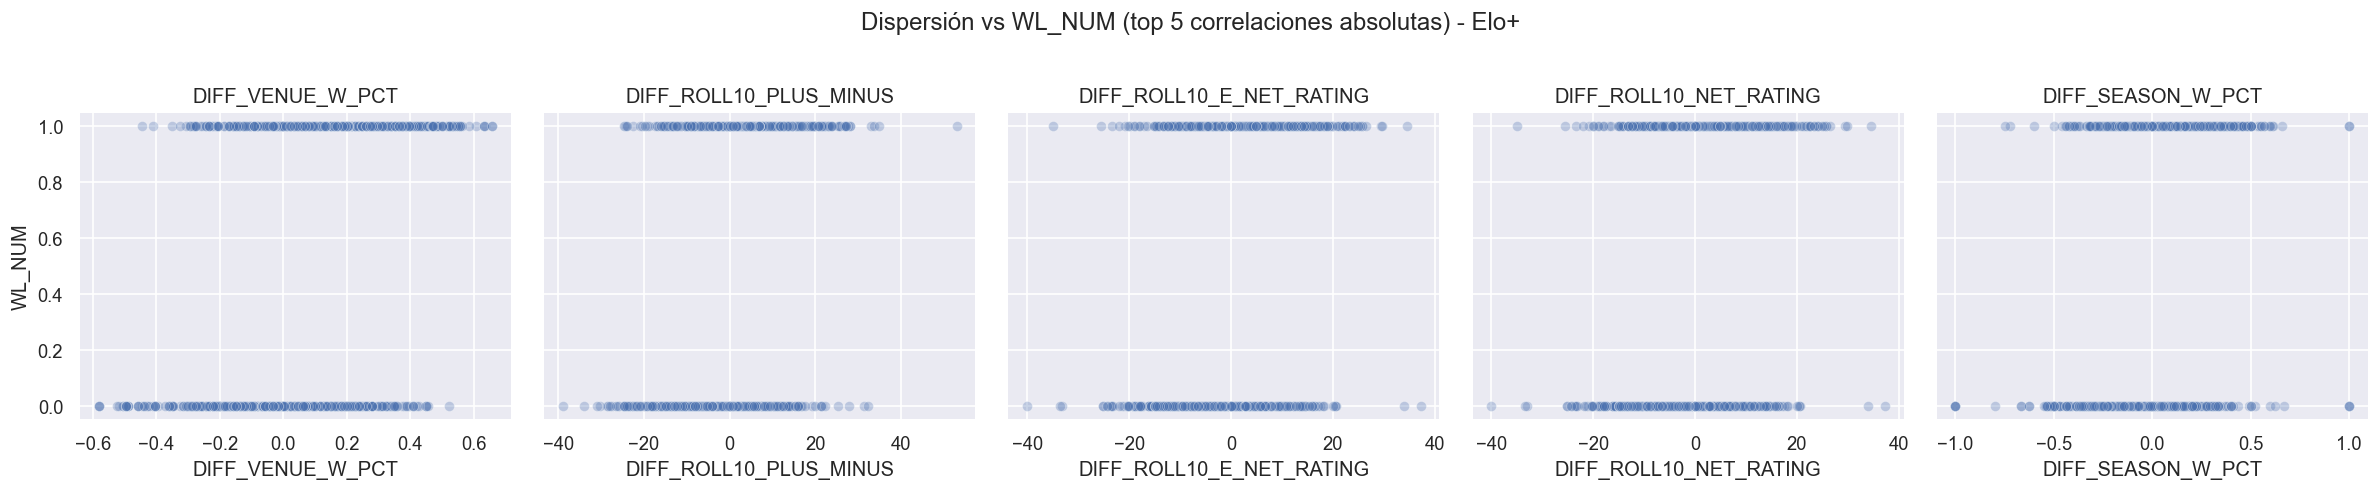

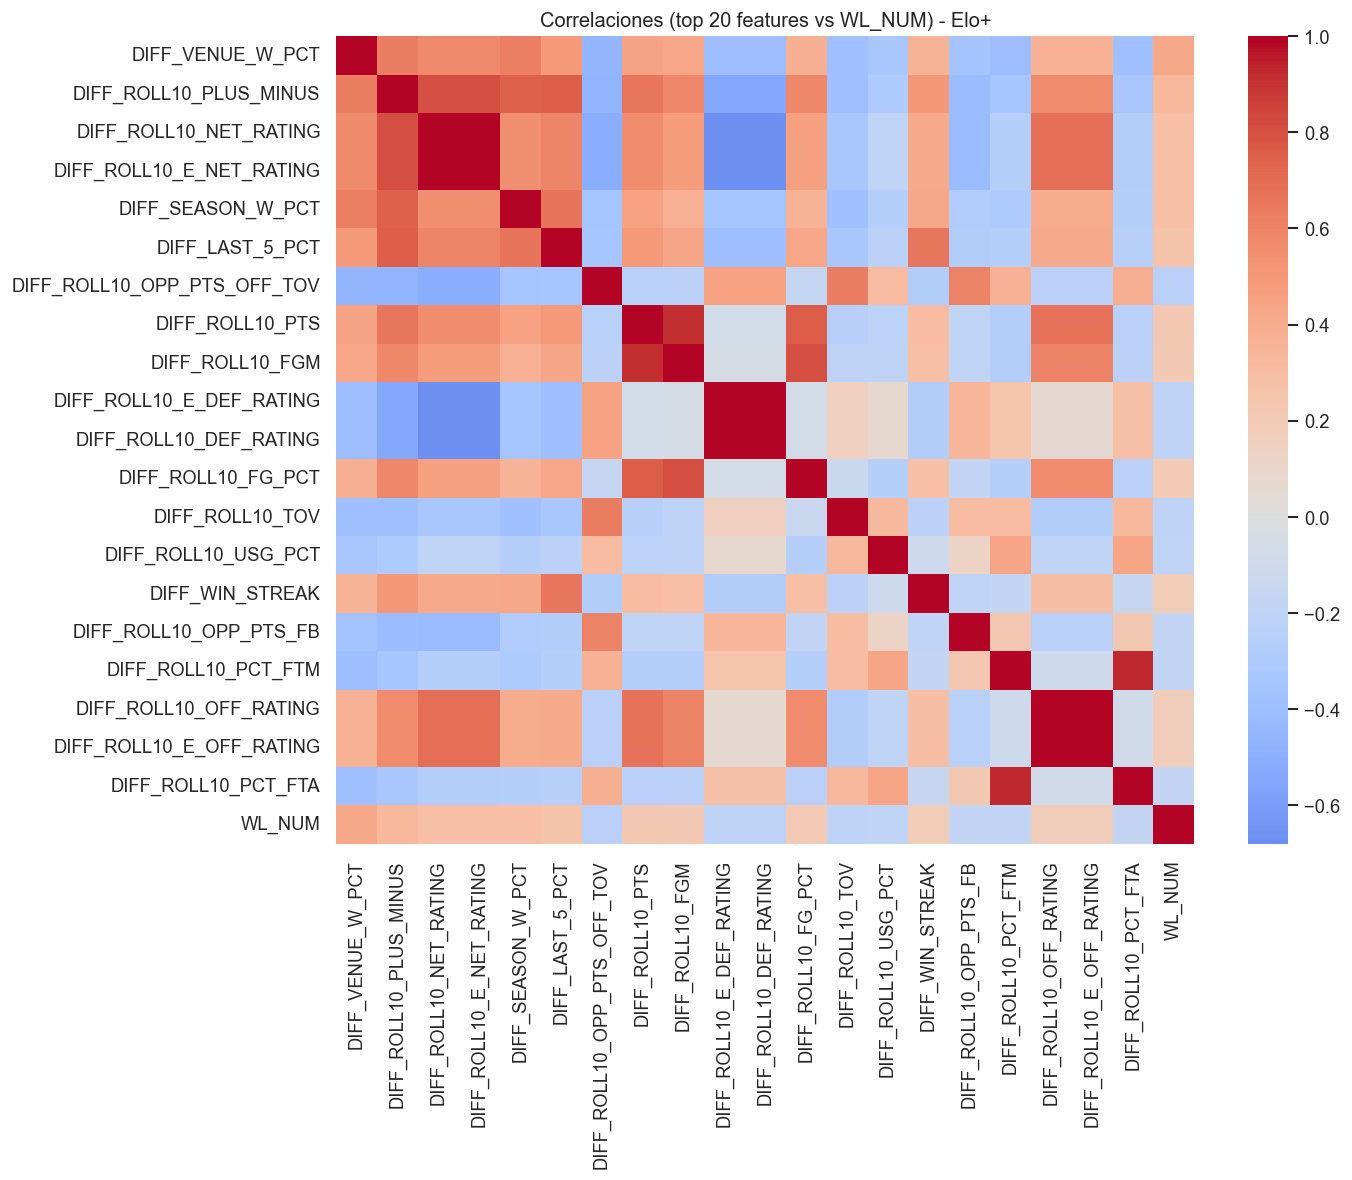

In [24]:
# === Visualizaciones para Elo+ ===
plot_scatter_grid(numeric_df_ext, elo_plus_features, TARGET_COLUMN, f"Dispersión vs WL_NUM (top {TOP_K_SCATTER} correlaciones absolutas) - Elo+", top_k=TOP_K_SCATTER)
plot_heatmap(numeric_df_ext, elo_plus_features, TARGET_COLUMN, f"Correlaciones (top {MAX_FEATURES_HEATMAP} features vs WL_NUM) - Elo+", max_features=MAX_FEATURES_HEATMAP)


In [25]:
# === Resumen específico de las nuevas columnas Elo+ ===
elo_plus_new_cols = [col for col in elo_plus_features if col not in feature_sets.get('Enhanced', [])]
available_new_corr = [col for col in elo_plus_new_cols if col in elo_plus_correlations.index]

if available_new_corr:
    summary_table = (
        pd.DataFrame({
            'Correlación': elo_plus_correlations.loc[available_new_corr],
        })
        .assign(**{'|Correlación|': lambda frame: frame['Correlación'].abs()})
        .sort_values('|Correlación|', ascending=False)
    )
    display(summary_table)
else:
    print('No hay correlaciones disponibles para las nuevas columnas añadidas por Elo+.')


,Correlación,|Correlación|
DIFF_GAMES_IN_3D,0.048388,0.048388
P_ELO_HOME,0.029678,0.029678
DIFF_ELO_PRE,0.029085,0.029085
DIFF_DAYS_REST_CALC,0.026254,0.026254
B2B_ADVANTAGE_ELO,0.022695,0.022695
DIFF_GAMES_IN_5D,0.020846,0.020846
DIFF_GAMES_IN_7D,0.019480,0.019480


Estas señales Elo dinámicas quedan listas para ser evaluadas en el cuaderno de modelado posterior, donde decidiremos si mantenerlas o descartarlas según su aporte incremental.
